# Bootstrap Resampling for Model Evaluation

## Overview

The bootstrap draws repeated samples with replacement from the dataset, fits the model on each sample, and evaluates on either the out-of-bag (OOB) observations or the original dataset. It estimates the sampling distribution of any statistic without analytical assumptions.

**Bootstrap estimators for model performance:**

| Estimator | Formula | Properties |
|---|---|---|
| **Naive bootstrap** | Error on original data using bootstrap model | Optimistically biased — evaluated on (partly) seen data |
| **OOB bootstrap** | Error on ~36.8% not sampled | Pessimistically biased for small n |
| **.632 bootstrap** | 0.368 × training error + 0.632 × OOB error | Corrects for both biases; best for small n |
| **.632+ bootstrap** | Adapts .632 weight to no-information rate | Best for nearly perfect or random classifiers |

**Why ~36.8%?** Each observation has probability $1-(1-1/n)^n \approx 1-e^{-1} \approx 0.632$ of being selected at least once in a bootstrap sample of size n, so ~36.8% of observations are left out on average.

**When to use bootstrap over k-fold CV:**
- Very small samples (n < 30): fewer holdout folds means each OOB set is more representative
- Estimating the uncertainty of a performance metric (CI on AUC, RMSE)
- Estimating the uncertainty of model coefficients
- The .632 bootstrap for corrected error estimation

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(rsample)     # bootstraps()
library(recipes)
library(parsnip)
library(workflows)
library(tune)
library(yardstick)
library(broom)
library(patchwork)

set.seed(42)

# Small dataset to demonstrate bootstrap advantages
n_small <- 60
boot_data <- tibble(
  nitrate    = rnorm(n_small, 3, 1.2),
  water_qual = rnorm(n_small, 6, 1.5),
  elevation  = rnorm(n_small, 200, 80),
  present    = factor(rbinom(n_small, 1,
                   plogis(-1 + 0.5*water_qual - 0.6*nitrate)),
                   levels=c(0,1), labels=c("absent","present"))
)

cat(sprintf("n=%d | Prevalence: %.1f%%\n",
            n_small, mean(boot_data$present=="present")*100))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'rsample' was built under R version 4.4.3"
Warning message:
"package 'recipes' was built under R version 4.

n=60 | Prevalence: 53.3%


---

## Bootstrap Performance Estimation

# A tibble: 2 × 6
  .metric  .estimator  mean     n std_err .config        
  <chr>    <chr>      <dbl> <int>   <dbl> <chr>          
1 accuracy binary     0.756   200 0.00583 pre0_mod0_post0
2 roc_auc  binary     0.812   200 0.00628 pre0_mod0_post0


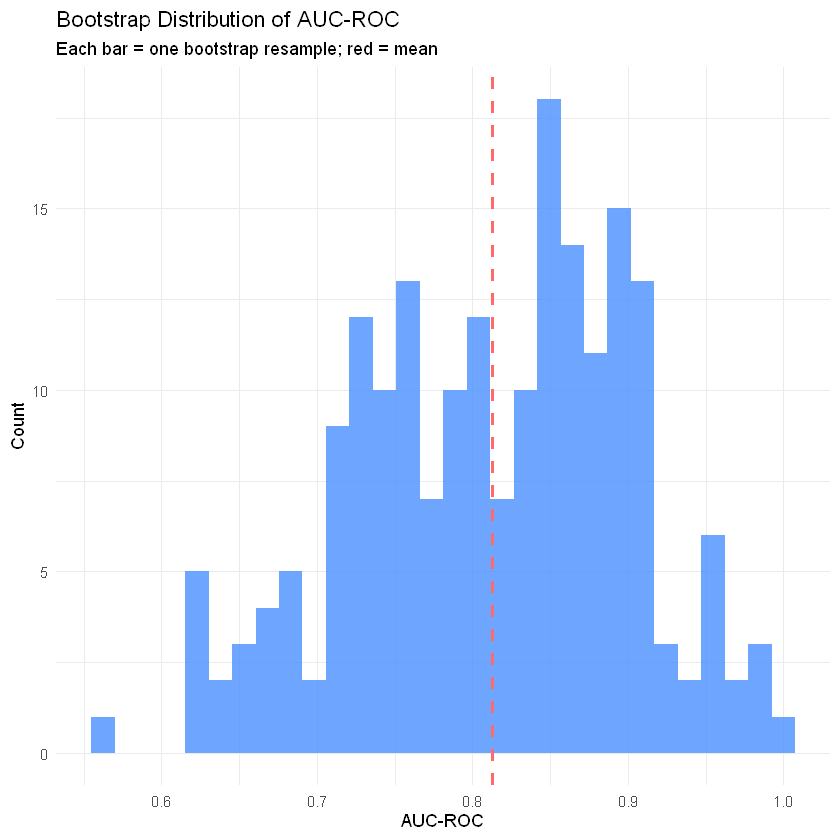

In [2]:
# Create 200 bootstrap resamples
boot_splits <- rsample::bootstraps(boot_data, times=200, strata=present)

rec <- recipe(present ~ nitrate + water_qual + elevation, data=boot_data) %>%
  step_normalize(all_numeric_predictors())

logit_spec <- logistic_reg() %>% set_engine("glm")
wf         <- workflow() %>% add_recipe(rec) %>% add_model(logit_spec)

# OOB performance: evaluate on the ~36.8% not sampled
boot_results <- tune::fit_resamples(
  wf,
  resamples = boot_splits,
  metrics   = metric_set(roc_auc, accuracy),
  control   = control_resamples(save_pred=TRUE)
)

boot_summary <- collect_metrics(boot_results)
print(boot_summary)

# Distribution of AUC across bootstrap resamples
boot_auc_dist <- collect_metrics(boot_results, summarize=FALSE) %>%
  filter(.metric=="roc_auc")

ggplot(boot_auc_dist, aes(x=.estimate)) +
  geom_histogram(bins=30, fill="#4a8fff", alpha=0.8, color=NA) +
  geom_vline(xintercept=mean(boot_auc_dist$.estimate),
             color="#ff6b6b", linewidth=1, linetype="dashed") +
  labs(title="Bootstrap Distribution of AUC-ROC",
       subtitle="Each bar = one bootstrap resample; red = mean",
       x="AUC-ROC", y="Count") +
  theme_minimal()

---

## The .632 Bootstrap Estimator

In [3]:
# .632 bootstrap corrects for the pessimism of OOB evaluation:
# error_632 = 0.368 * training_error + 0.632 * oob_error

compute_632 <- function(splits, wf, metric_fn) {
  map_dfr(splits$splits, function(sp) {
    train_fold <- analysis(sp)
    oob_fold   <- assessment(sp)

    fit_obj  <- fit(wf, data=train_fold)

    # Training error (apparent error)
    train_preds <- augment(fit_obj, new_data=train_fold)
    train_err   <- 1 - metric_fn(train_preds, truth=present,
                                  .pred_present, event_level="second")$.estimate

    # OOB error
    oob_preds <- augment(fit_obj, new_data=oob_fold)
    oob_err   <- 1 - metric_fn(oob_preds, truth=present,
                                .pred_present, event_level="second")$.estimate

    tibble(train_err=train_err, oob_err=oob_err,
           err_632 = 0.368*train_err + 0.632*oob_err)
  })
}

boot_50 <- rsample::bootstraps(boot_data, times=50, strata=present)
err_df  <- compute_632(boot_50, wf, yardstick::roc_auc)

err_summary <- tibble(
  estimator   = c("Training (apparent)", "OOB", ".632 Bootstrap"),
  mean_error  = c(mean(err_df$train_err),
                  mean(err_df$oob_err),
                  mean(err_df$err_632)),
  se          = c(sd(err_df$train_err)/sqrt(50),
                  sd(err_df$oob_err)/sqrt(50),
                  sd(err_df$err_632)/sqrt(50))
) %>%
  mutate(
    mean_auc  = round(1 - mean_error, 4),
    se        = round(se, 4)
  )

print(err_summary)
# Training AUC is optimistic (upper bound)
# OOB AUC is pessimistic (lower bound, especially at small n)
# .632 is between the two — the most honest estimate

# A tibble: 3 × 4
  estimator           mean_error     se mean_auc
  <chr>                    <dbl>  <dbl>    <dbl>
1 Training (apparent)      0.127 0.006     0.873
2 OOB                      0.201 0.0131    0.798
3 .632 Bootstrap           0.174 0.0073    0.826


---

## Bootstrap Confidence Intervals for Coefficients

In [4]:
# Bootstrap CIs for logistic regression coefficients
# Useful when parametric assumptions are in doubt

boot_coefs <- map_dfr(
  boot_50$splits,
  function(sp) {
    d <- analysis(sp)
    m <- glm(present ~ nitrate + water_qual + elevation,
             data=d, family=binomial)
    broom::tidy(m) %>% select(term, estimate)
  }
)

# Percentile bootstrap CI
ci_df <- boot_coefs %>%
  group_by(term) %>%
  summarise(
    boot_mean = mean(estimate),
    ci_low    = quantile(estimate, 0.025),
    ci_high   = quantile(estimate, 0.975),
    .groups   = "drop"
  ) %>%
  filter(term != "(Intercept)") %>%
  mutate(across(where(is.numeric), ~round(.x, 3)))

# Parametric CI for comparison
param_fit <- glm(present ~ nitrate + water_qual + elevation,
                 data=boot_data, family=binomial)
param_ci  <- broom::tidy(param_fit, conf.int=TRUE) %>%
  filter(term != "(Intercept)") %>%
  select(term, estimate, conf.low, conf.high)

# Side-by-side comparison
inner_join(ci_df, param_ci, by="term") %>%
  transmute(
    term,
    param_estimate = round(estimate, 3),
    param_ci       = sprintf("[%.3f, %.3f]", conf.low, conf.high),
    boot_estimate  = boot_mean,
    boot_ci        = sprintf("[%.3f, %.3f]", ci_low, ci_high)
  ) %>% print()

# Substantial agreement: good sign for parametric assumptions
# Large divergence: parametric assumptions may be violated

# A tibble: 3 × 5
  term       param_estimate param_ci         boot_estimate boot_ci         
  <chr>               <dbl> <chr>                    <dbl> <chr>           
1 elevation           0.007 [-0.002, 0.017]          0.008 [0.001, 0.018]  
2 nitrate            -1.14  [-1.925, -0.553]        -1.46  [-3.349, -0.694]
3 water_qual          0.594 [0.113, 1.160]           0.659 [-0.064, 1.405] 


---

## Common Pitfalls

**1. Using the naive bootstrap (training error on bootstrap samples) as the performance estimate**  
The naive bootstrap evaluates the model on data it was trained on. Because bootstrap samples contain ~63% of the original observations, the model has partially seen the evaluation data — giving an optimistically biased estimate. Always use OOB evaluation or the .632 estimator.

**2. Using too few bootstrap resamples**  
The variance of bootstrap estimates decreases with the number of resamples. For stable confidence intervals, use B ≥ 1000 resamples. For quick estimates during development, B = 100–200 is adequate, but do not report CIs from fewer than 500 resamples.

**3. Not using the .632 bootstrap with small samples**  
With n < 50, OOB folds contain only ~18 observations on average — giving noisy per-fold estimates. The .632 estimator reduces this noise by blending training and OOB performance. At larger n (> 200), OOB and .632 converge and the distinction matters less.

**4. Forgetting to refit preprocessing inside each bootstrap resample**  
The same leakage problem applies to bootstrap CV: scaling, imputation, and encoding must be refit inside each resample. Using `fit_resamples()` with a `workflow()` handles this correctly.

**5. Using percentile bootstrap CIs when the sampling distribution is skewed**  
The percentile CI assumes the bootstrap distribution is symmetric around the estimate. For skewed distributions (e.g., variance parameters, small AUC values), use the BCa (bias-corrected and accelerated) bootstrap instead, available in the `boot` package via `boot.ci(type="bca")`.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*